# Data

In [147]:
import os
import functions
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

csvs = [file for file in os.listdir('./Data/LondonHydro/') if file.endswith('.csv')]
df_name = csvs[0]
df = pd.read_csv(f'./Data/LondonHydro/{df_name}')


numerical_columns = ['energy_consumption', 'temperature', 'humidity', 'wind_speed']
categorical_columns = None
binary_columns = None
datetime_column = 'timestamp'
target_column = 'energy_consumption'

df[target_column] = df[target_column] + 1

df = functions.pre_process(df, numerical_columns, categorical_columns, binary_columns, datetime_column, target_column)

df = functions.get_datetime_features(df, datetime_column, cos_sin = False)

feature_names = ["Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend", "temperature", "humidity", "wind_speed", "energy_consumption"]
df = df[feature_names]

#scale type = both, features, outcome
X_train, y_train, X_val, y_val, X_test, y_test, X, y, df_scaled = functions.load_and_preprocess_data_with_sequences(df, target='energy_consumption', scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, input_seq_length=48, output_seq_length=24)

# Print shapes to verify
print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

df_scaled.head()


Shapes:
X_train: (20391, 48, 10)
y_train: (20391, 24, 1)
X_val: (2548, 48, 10)
y_val: (2548, 24, 1)
X_test: (2548, 48, 10)
y_test: (2548, 24, 1)


,Hour,DayOfWeek,DayOfMonth,Month,DayOfYear,IsWeekend,temperature,humidity,wind_speed,energy_consumption
timestamp,,,,,,,,,,
2002-01-01 01:00:00,0.043478,0.166667,0.0,0.0,0.0,0.0,0.312925,0.760000,0.270270,1.29
2002-01-01 02:00:00,0.086957,0.166667,0.0,0.0,0.0,0.0,0.302721,0.786667,0.270270,1.27
2002-01-01 03:00:00,0.130435,0.166667,0.0,0.0,0.0,0.0,0.287415,0.826667,0.256757,1.31
2002-01-01 04:00:00,0.173913,0.166667,0.0,0.0,0.0,0.0,0.278912,0.853333,0.175676,1.25
2002-01-01 05:00:00,0.217391,0.166667,0.0,0.0,0.0,0.0,0.277211,0.853333,0.148649,1.30


# HyperParameter and Training the best model

[I 2024-08-27 09:21:54,003] A new study created in memory with name: no-name-11090fd6-4078-4a9a-a592-4675899e5c00
[I 2024-08-27 09:23:16,367] Trial 0 finished with value: 0.2701755166053772 and parameters: {'lstm_units': 77, 'dropout_rate': 0.2208784614179999, 'num_lstm_layers': 1, 'learning_rate': 0.00018302387694011914}. Best is trial 0 with value: 0.2701755166053772.
[I 2024-08-27 09:24:25,182] Trial 1 finished with value: 0.2726292610168457 and parameters: {'lstm_units': 105, 'dropout_rate': 0.28057686687120154, 'num_lstm_layers': 1, 'learning_rate': 0.0005357919147932363}. Best is trial 0 with value: 0.2701755166053772.
[I 2024-08-27 09:30:10,882] Trial 2 finished with value: 0.24658876657485962 and parameters: {'lstm_units': 98, 'dropout_rate': 0.2391099753043286, 'num_lstm_layers': 2, 'learning_rate': 0.0008213475526410589}. Best is trial 2 with value: 0.24658876657485962.
[I 2024-08-27 09:31:15,508] Trial 3 finished with value: 0.2652590274810791 and parameters: {'lstm_units': 

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


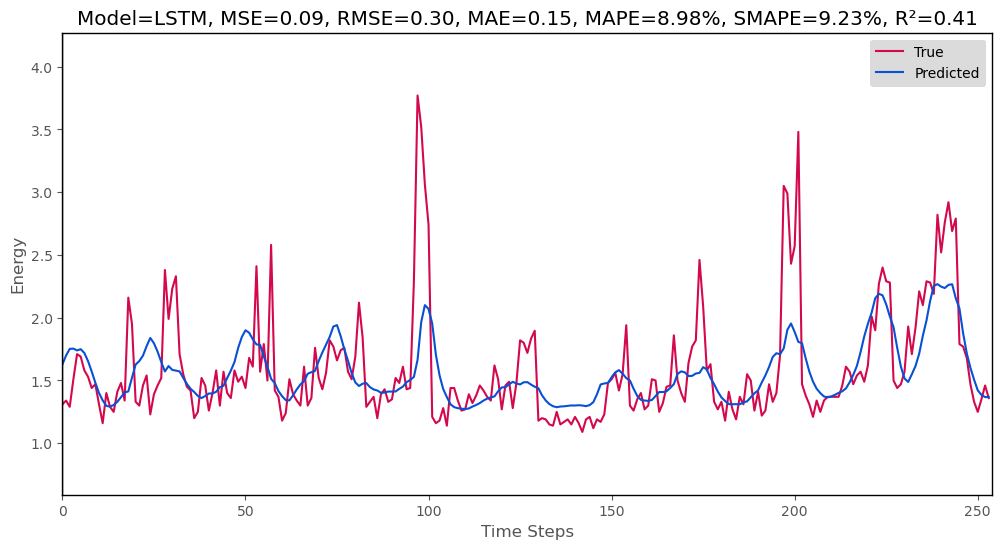

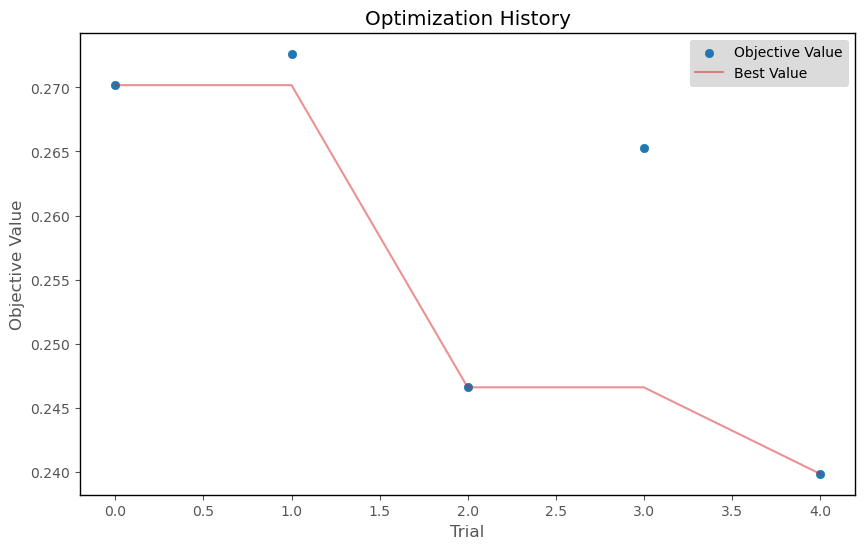

In [152]:
# model_types = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']
model_types = ['LSTM']

# Example usage
data = (X_train, y_train, X_val, y_val, X_test, y_test)

for model_type in model_types:
    best_model = functions.optimize_and_save_model(data, df_name, n_trials=5, epochs=100, verbosity=0, model_type=model_type)
    # best_rf = optimize_and_save_rf_model(data, df_name, n_trials=2, verbosity=1, model_type=model_type)

# Background Data

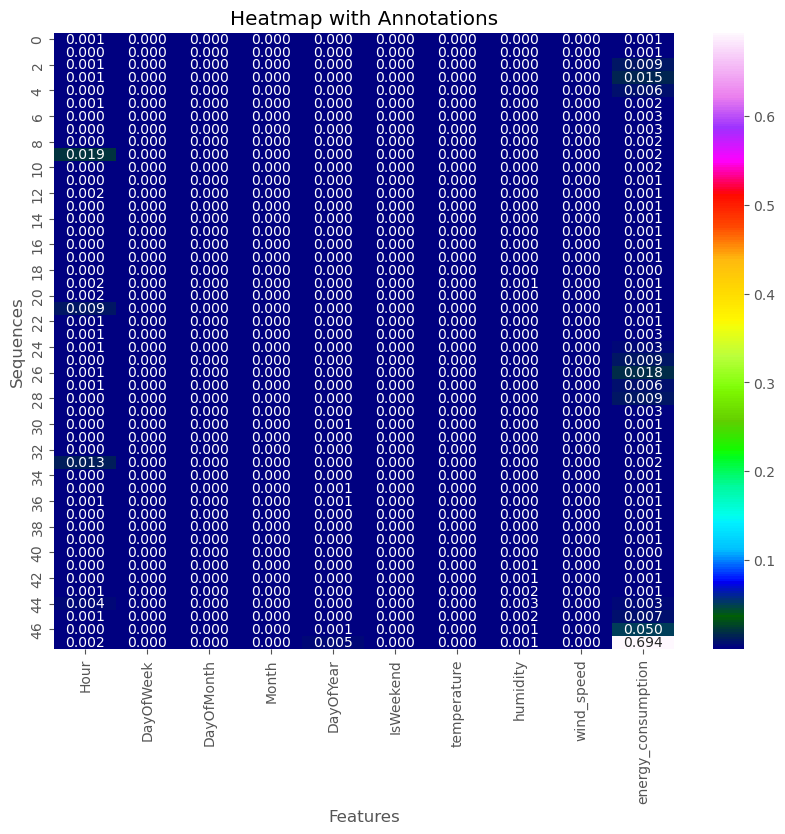

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

model_type = 'CNN'

# Load the saved Random Forest model
model_path = f"./Results/Models/{df_name}/{model_type}_RandomForest.pkl"
best_rf = joblib.load(model_path)

# Get the feature importances
feature_importances = best_rf.feature_importances_

# Assuming we have 48 sequences (rows) and 10 features (columns)
n_sequences = 48
n_features = 10

# Reshape into a 48x10 dataframe
importances_reshaped = feature_importances.reshape(n_sequences, n_features)
importances_df = pd.DataFrame(importances_reshaped, columns=df.columns)

# Approach 2: Heatmap with Annotations
plt.figure(figsize=(10, 8))
sns.heatmap(importances_df, cmap='gist_ncar', annot=True, fmt=".3f")
plt.title('Heatmap with Annotations')
plt.xlabel('Features')
plt.ylabel('Sequences')
plt.show()

Hour                  0.067854
DayOfWeek             0.001667
DayOfMonth            0.003373
Month                 0.000205
DayOfYear             0.013336
IsWeekend             0.000198
temperature           0.007440
humidity              0.022685
wind_speed            0.008984
energy_consumption    0.874258
dtype: float64


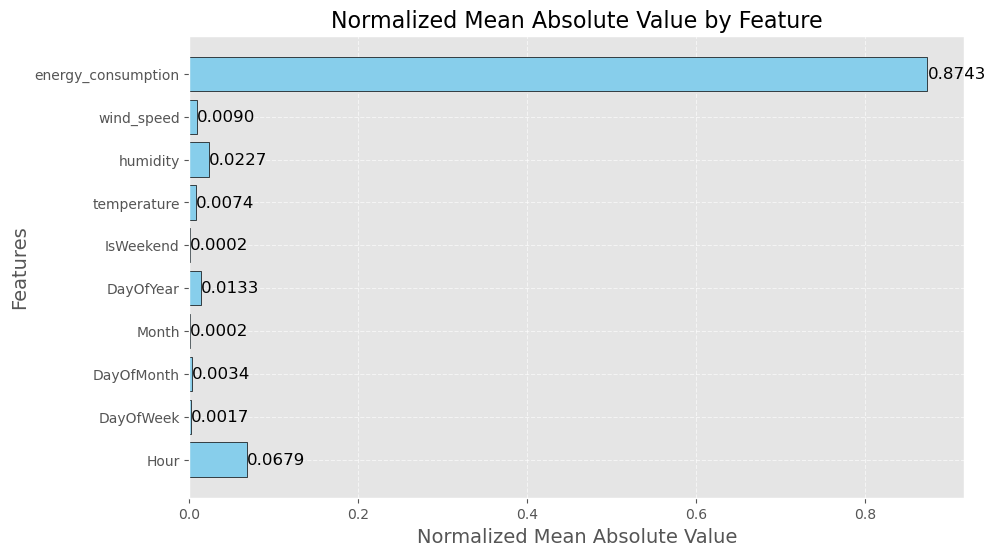

In [159]:
import pandas as pd
import numpy as np

# Assuming importances_df is your DataFrame
mean_absolute_values = importances_df.apply(lambda x: np.mean(np.abs(x)))

# Normalize so that the sum is 1
normalized_values = mean_absolute_values / mean_absolute_values.sum()

# Display the normalized result
print(normalized_values)

# Convert the normalized values to lists
features = list(normalized_values.index)  # Using .index for Pandas Series
mean_abs_values = list(normalized_values.values)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(features, mean_abs_values, color='skyblue', edgecolor='black')

# Adding titles and labels
plt.title('Normalized Mean Absolute Value by Feature', fontsize=16)
plt.xlabel('Normalized Mean Absolute Value', fontsize=14)
plt.ylabel('Features', fontsize=14)

# Adding grid
plt.grid(True, linestyle='--', alpha=0.6)

# Annotating the bars with the values
for index, value in enumerate(mean_abs_values):
    plt.text(value, index, f'{value:.4f}', va='center', ha='left', fontsize=12)

# Show the plot
plt.show()


# Explaination

In [178]:
import numpy as np
import pandas as pd
import shap
from sklearn.neighbors import NearestNeighbors

import numpy as np
from sklearn.neighbors import NearestNeighbors

# Function to find the most relevant background data based on weighted cosine similarity
def select_relevant_background_data(X_train, test_instance, weights = normalized_values.values.flatten(), num_neighbors=10):
    # Flatten the test instance and training data
    test_instance_flattened = test_instance.flatten().reshape(1, -1)
    X_train_flattened = X_train.reshape(X_train.shape[0], -1)

    # Adjust weights to match the shape of test_instance_flattened
    weights = np.tile(weights, X_train.shape[1])  # Repeat the weights along the time dimension


    # Apply weights to the flattened data
    test_instance_weighted = test_instance_flattened * weights
    X_train_weighted = X_train_flattened * weights

    # Compute weighted cosine similarity using NearestNeighbors
    knn = NearestNeighbors(n_neighbors=num_neighbors, metric='cosine')
    knn.fit(X_train_weighted)
    distances, indices = knn.kneighbors(test_instance_weighted)

    return X_train[indices[0]]

# Function to calculate SHAP values
def my_shap(model, background_training, new_data, general_method=0.01, horizon=0, similar_background=False, num_neighbors=100):
    if similar_background:
        background_training = select_relevant_background_data(background_training, new_data, num_neighbors=num_neighbors)
    else:
        background_training = background_training[:int(background_training.shape[0] * general_method)]

    # Prepare background data (flattened for KernelExplainer)
    background_data = background_training.reshape(background_training.shape[0], -1)  # Flatten to 2D matrix
    test_data = new_data.reshape(new_data.shape[0], -1)  # Flatten to 2D matrix for explanation

    # Define a prediction function that reshapes the 2D input back to 3D
    def model_predict(data):
        reshaped_data = data.reshape((-1, new_data.shape[1], new_data.shape[2]))
        return model.predict(reshaped_data)

    # Initialize the SHAP KernelExplainer
    explainer = shap.KernelExplainer(model_predict, background_data)

    # Calculate SHAP values
    shap_values = explainer.shap_values(test_data)

    # Calculate the baseline predictions using the background data
    baseline_predictions = model_predict(background_data).mean(axis=0)

    # Create DataFrame for SHAP values
    shap_df = pd.DataFrame(shap_values[0,:,horizon].reshape(new_data.shape[1], new_data.shape[2]))

    result = {'explainer': explainer, 'shap_values': shap_values, 'shap_df': shap_df, 'background_training': background_training, 'baseline_predictions': baseline_predictions}
    return result


In [169]:
result = my_shap(best_model, background_training = X_train, new_data = X_test[:1], general_method = 0.001, horizon = 0, similar_background=False, num_neighbors=100)

# Visualizing the SHAP values
shap_df = result['shap_df']
shap_df.columns = df.columns

shap_values = result['shap_values']
explainer = result['explainer']
background_training = result['background_training']
baseline_predictions = result['baseline_predictions']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [203]:
time_id = 2
new_data = X_test[:1]
data = new_data[0,time_id,:]
data

background_data = pd.DataFrame(background_training[:,0,:].reshape(background_training[:,0,:].shape[0], background_training[:,0,:].shape[1]), columns=feature_names)

shap_values = np.array(shap_df.loc[time_id,:])

# Create a SHAP Explanation object
explanation = shap.Explanation(values=shap_values, base_values=base_values-1, data=data, feature_names=feature_names)

# Visualize the SHAP values with a force plot including feature names
shap.initjs()
shap.force_plot(explanation.base_values, explanation.values, explanation.data, feature_names=explanation.feature_names)


# similar method

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
9400/9400 ━━━━━━━━━━━━━━━━━━━━ 183s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


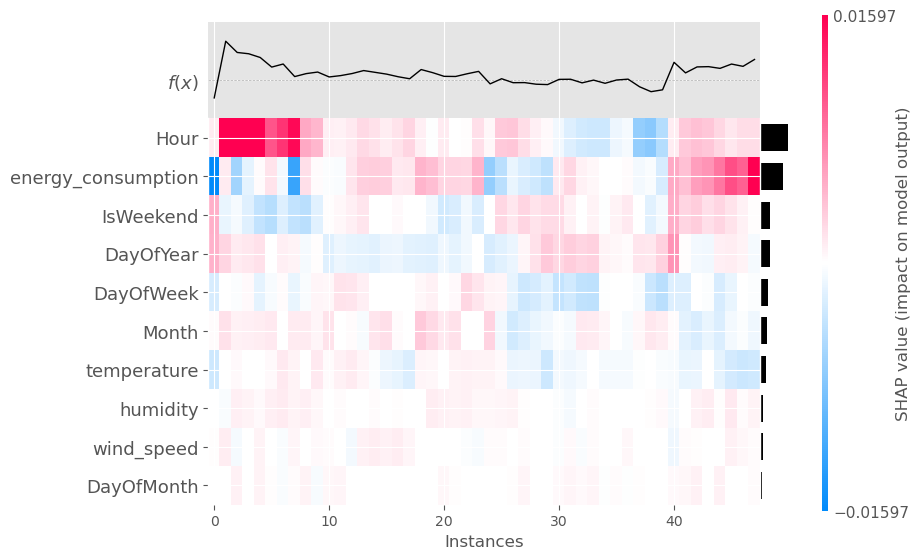

<Axes: xlabel='Instances'>

In [205]:
result = my_shap(best_model, background_training = X_train, new_data = X_test[:1], general_method = 0.001, horizon = 0, similar_background=True, num_neighbors=100)

# feature_names = ["temperature", "humidity", "wind_speed", "energy_consumption", "Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend"]

new_data = X_test[:1]

# Visualizing the SHAP values
shap_df = result['shap_df']
shap_df.columns = feature_names

shap_values = result['shap_values']
explainer = result['explainer']
background_training = result['background_training']
baseline_predictions = result['baseline_predictions']

shap_values_new = np.array(shap_df)
shap_data_new = new_data[0,:,:]
# base_values_new = np.full((shap_data.shape[0],), abs(y_test[0][0][0] - base_values))  # 10 is the size of the array, 5 is the repeated value
base_values_new = np.full((shap_df.shape[0],), baseline_predictions[0]-1) #first hirozon)  # 10 is the size of the array, 5 is the repeated value

# Create a SHAP Explanation object
explanation = shap.Explanation(values=shap_values_new, base_values=base_values_new, data=shap_data_new, feature_names=df.columns)

# Visualize the SHAP values with a force plot including feature names
shap.plots.heatmap(explanation)


# general method

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


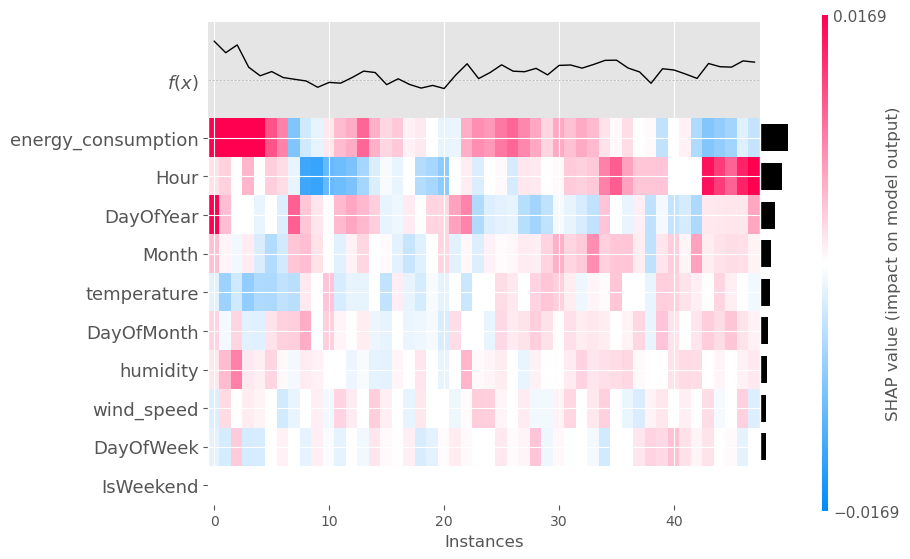

<Axes: xlabel='Instances'>

In [206]:
result = my_shap(best_model, background_training = X_train, new_data = X_test[:1], general_method = 0.001, horizon = 0, similar_background=False, num_neighbors=100)

# feature_names = ["temperature", "humidity", "wind_speed", "energy_consumption", "Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend"]

new_data = X_test[:1]

# Visualizing the SHAP values
shap_df = result['shap_df']
shap_df.columns = feature_names

shap_values = result['shap_values']
explainer = result['explainer']
background_training = result['background_training']
baseline_predictions = result['baseline_predictions']

shap_values_new = np.array(shap_df)
shap_data_new = new_data[0,:,:]
# base_values_new = np.full((shap_data.shape[0],), abs(y_test[0][0][0] - base_values))  # 10 is the size of the array, 5 is the repeated value
base_values_new = np.full((shap_df.shape[0],), baseline_predictions[0]-1) #first hirozon)  # 10 is the size of the array, 5 is the repeated value

# Create a SHAP Explanation object
explanation = shap.Explanation(values=shap_values_new, base_values=base_values_new, data=shap_data_new, feature_names=df.columns)

# Visualize the SHAP values with a force plot including feature names
shap.plots.heatmap(explanation)
